In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        #print(os.path.join(dirname, filename))
        pass

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [6]:
# Change path to where you downloaded the CSV
path = "/kaggle/input/datasets/camnugent/sandp500/all_stocks_5yr.csv"
df = pd.read_csv(path)  
df["date"] = pd.to_datetime(df["date"])


df_compare.head()
df.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [9]:
stocks = ["AMD", "INTC"]
df_compare = df[df["Name"].isin(stocks)].copy()
##df_compare

,date,open,high,low,close,volume,Name
38833,2013-02-08,2.580,2.60,2.5800,2.59,5971768,AMD
38834,2013-02-11,2.590,2.70,2.5900,2.67,22410941,AMD
38835,2013-02-12,2.705,2.78,2.6900,2.77,13675442,AMD
38836,2013-02-13,2.810,2.83,2.7300,2.75,11481985,AMD
38837,2013-02-14,2.740,2.75,2.6900,2.75,13283766,AMD
...,...,...,...,...,...,...,...
300211,2018-02-01,47.695,48.47,47.4500,47.65,28840380,INTC
300212,2018-02-02,47.320,47.79,46.1000,46.15,28663029,INTC
300213,2018-02-05,46.350,47.26,44.5000,44.52,47869041,INTC
300214,2018-02-06,44.020,44.93,43.0302,44.91,58145381,INTC


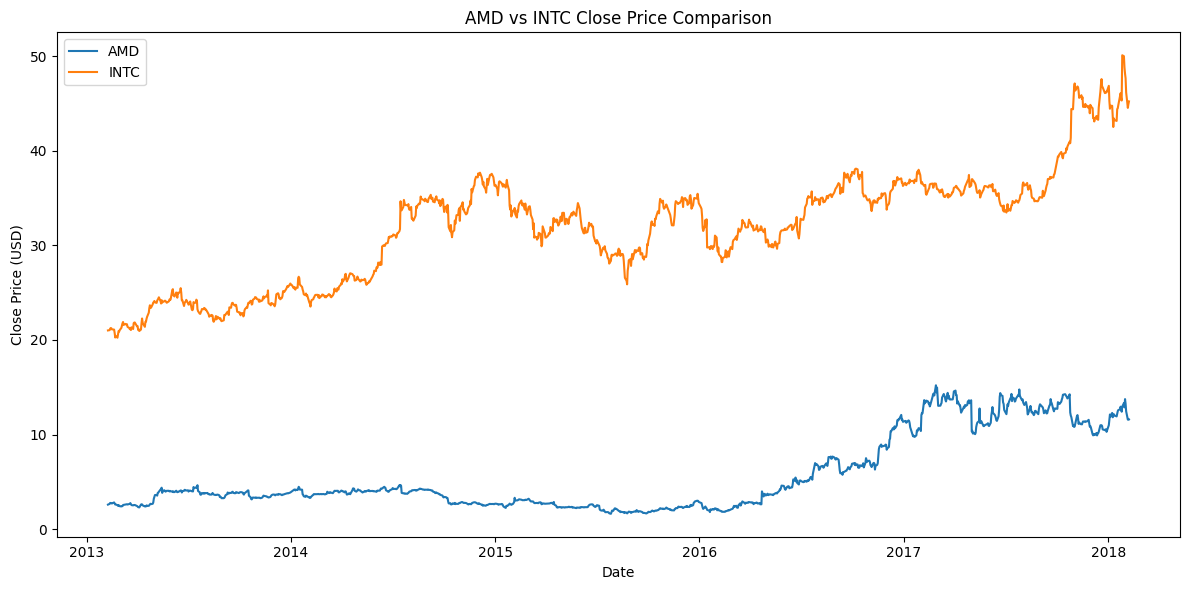

In [10]:
plt.figure(figsize=(12,6))

for stock in stocks:
    data = df_compare[df_compare["Name"] == stock]
    plt.plot(data["date"], data["close"], label=stock)

plt.title("AMD vs INTC Close Price Comparison")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

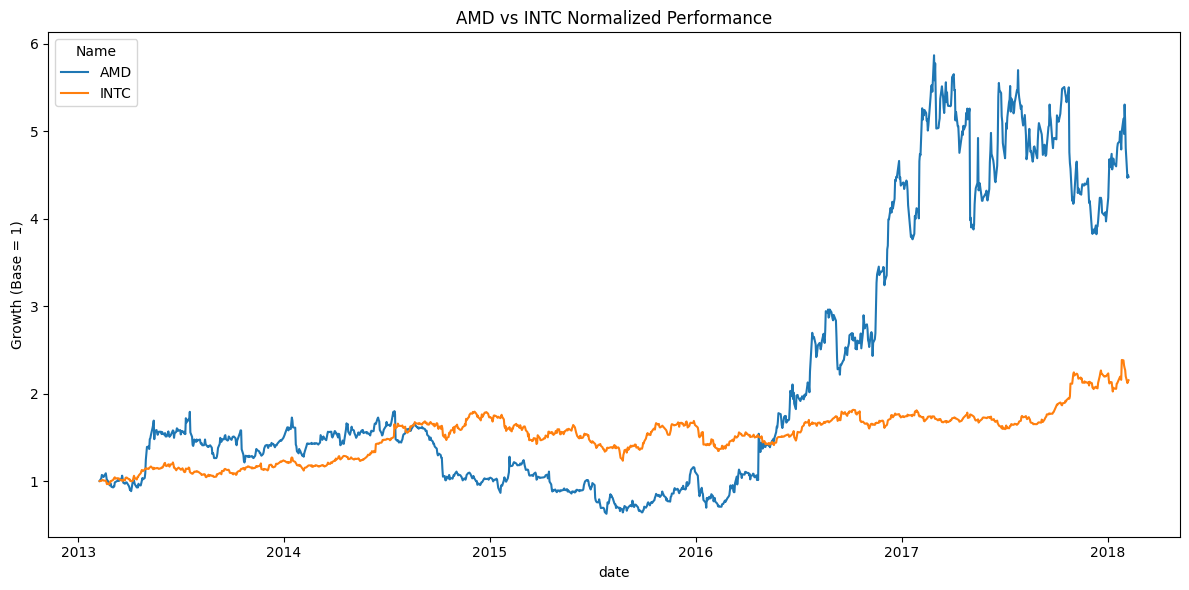

In [11]:
df_norm = df_compare.copy()

df_norm["Normalized"] = df_norm.groupby("Name")["close"].transform(lambda x: x / x.iloc[0])

plt.figure(figsize=(12,6))
sns.lineplot(data=df_norm, x="date", y="Normalized", hue="Name")
plt.title("AMD vs INTC Normalized Performance")
plt.ylabel("Growth (Base = 1)")
plt.tight_layout()
plt.show()

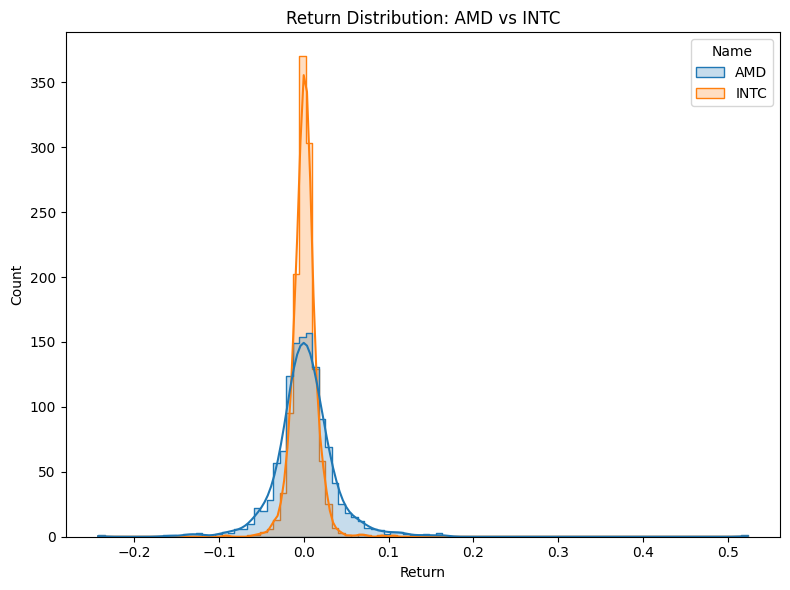

In [12]:
df_compare["Return"] = df_compare.groupby("Name")["close"].pct_change()

plt.figure(figsize=(8,6))
sns.histplot(data=df_compare, x="Return", hue="Name", bins=100, kde=True, element="step")
plt.title("Return Distribution: AMD vs INTC")
plt.tight_layout()
plt.show()

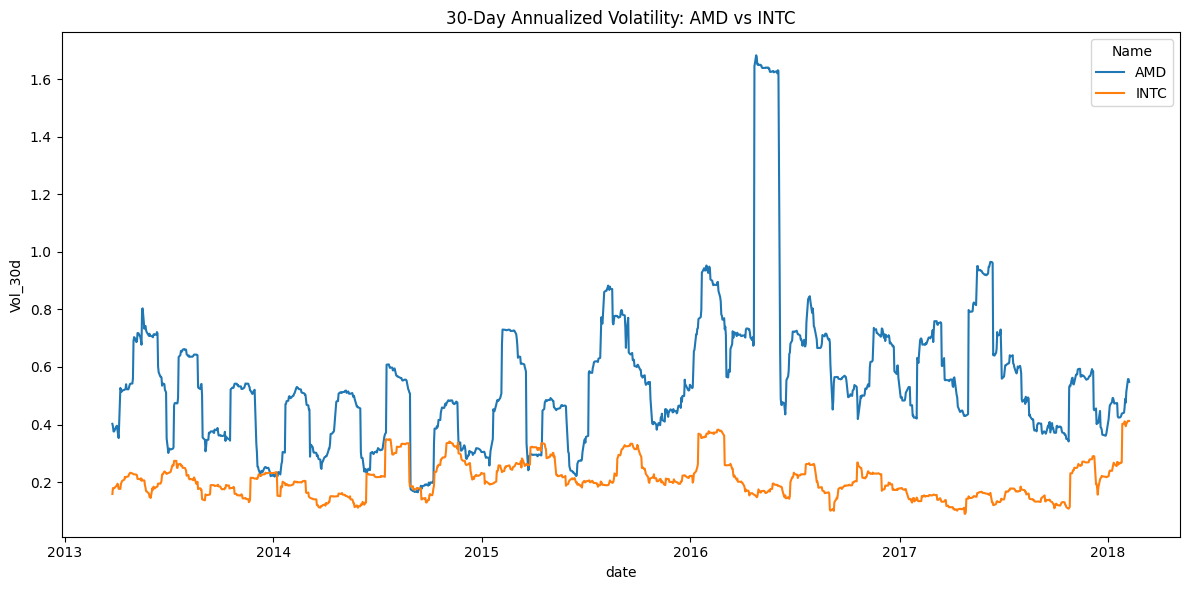

In [13]:
df_compare["Vol_30d"] = (
    df_compare.groupby("Name")["Return"]
    .rolling(30)
    .std()
    .reset_index(level=0, drop=True) * np.sqrt(252)
)

df_vol = df_compare.dropna(subset=["Vol_30d"])

plt.figure(figsize=(12,6))
sns.lineplot(data=df_vol, x="date", y="Vol_30d", hue="Name")
plt.title("30-Day Annualized Volatility: AMD vs INTC")
plt.tight_layout()
plt.show()

In [15]:
fig = px.line(df_compare, x="date", y="close", color="Name",
              title="AMD vs INTC (Interactive Price Chart)")
fig.show()